In [26]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import pickle

%load_ext autoreload
%autoreload 2

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
def ann_subset_perf(filespec):
    fname = 'measures_6to31_' + filespec + '.pkl'
    with open(fname, 'rb') as f:
        measures = pickle.load(f)
        
    mess = ['RMSE', 'MAE', 'R2', 'EVS', 'FIE_H', 'FIE_O', 'FIE_OH', 'LINCC']
    
    varset, target = filespec.split('_')
    if target == 'hh0':
        indices = [varset + ' 6 Stat', varset + ' 31 Stat']
    elif target == 'h':
        indices = [varset + ' H 6 Stat', varset + ' H 31 Stat']
    
    
    test6 = np.array(measures['te6'])
    test31 = np.array(measures['te31'])
    
    assert test6.shape == test31.shape
    assert test6.shape == (50,8)
    
    means6 = test6.mean(axis=0, keepdims=True)
    means31 = test31.mean(axis=0, keepdims=True)
    means = np.concatenate([means6, means31])
    df_mean = pd.DataFrame(means, columns=mess, index=indices)
    return df_mean

In [5]:
tries = ['nN_hh0', 'nN_h', 'nNPhi_hh0', 'nNPhi_h', 'nNT_hh0', 'nNT_h', 'nNTPhi_hh0', 'nNTPhi_h']

for trial in tries:
    if trial == 'nN_hh0':
        table = ann_subset_perf(trial)
    else:
        table = pd.concat([table, ann_subset_perf(trial)])
    
print(table)

                      RMSE       MAE        R2       EVS     FIE_H     FIE_O  \
nN 6 Stat         3.944094  1.974144  0.788156  0.793209  0.271043  0.494249   
nN 31 Stat        3.874698  1.942584  0.795616  0.799154  0.277339  0.504462   
nN H 6 Stat       4.337618  2.223713  0.742940  0.759827  0.217829  0.413913   
nN H 31 Stat      3.992442  2.071650  0.782867  0.795600  0.244798  0.455705   
nNPhi 6 Stat      3.986129  2.196928  0.783551  0.787969  0.214332  0.402090   
nNPhi 31 Stat     4.134307  2.135766  0.766684  0.779115  0.245851  0.459851   
nNPhi H 6 Stat    4.378701  2.367087  0.738328  0.755075  0.199097  0.376694   
nNPhi H 31 Stat   4.123547  2.111724  0.767884  0.782036  0.243996  0.451872   
nNT 6 Stat        4.049768  1.934483  0.776662  0.780706  0.291846  0.524193   
nNT 31 Stat       3.886870  1.883770  0.794310  0.798286  0.299396  0.533464   
nNT H 6 Stat      4.210511  2.135448  0.758183  0.771732  0.235453  0.442947   
nNT H 31 Stat     4.015187  2.020424  0.

In [11]:
mess = ['RMSE', 'MAE', 'R2', 'EVS', 'FIE_H', 'FIE_O', 'FIE_OH', 'LINCC']
indices = ['Universal', 'Quad nN 6 Stat', 'Quad nN 31 Stat', 'Quad nNT 6 Stat', 'Quad nNT 31 Stat']

uni = np.array([[6.2895, 2.5645, 0.4616, 0.5120, 0.1737, 0.3439, 0.5000, 0.7624915439373603]])
quad_nN_6 = np.array([[4.0293, 2.0793, 0.7790, 0.7943, 0.2437, 0.4523, 0.6081, 0.8849593555399916]])
quad_nN_31 = np.array([[3.8588, 2.0309, 0.7973, 0.8092, 0.2477, 0.4622, 0.6171, 0.8933090982680278]])
quad_nNT_6 = np.array([[4.0728, 2.1512, 0.7742, 0.7928, 0.2347, 0.4277, 0.5815, 0.8779379261072009]])
quad_nNT_31 = np.array([[3.9457, 2.0692, 0.7881, 0.8026, 0.2450, 0.4475, 0.6052, 0.8861007701905707]])

classical = np.concatenate([uni, quad_nN_6, quad_nN_31, quad_nNT_6, quad_nNT_31], axis=0)
df_cl = pd.DataFrame(classical, columns=mess, index=indices)
print(df_cl)

                    RMSE     MAE      R2     EVS   FIE_H   FIE_O  FIE_OH  \
Universal         6.2895  2.5645  0.4616  0.5120  0.1737  0.3439  0.5000   
Quad nN 6 Stat    4.0293  2.0793  0.7790  0.7943  0.2437  0.4523  0.6081   
Quad nN 31 Stat   3.8588  2.0309  0.7973  0.8092  0.2477  0.4622  0.6171   
Quad nNT 6 Stat   4.0728  2.1512  0.7742  0.7928  0.2347  0.4277  0.5815   
Quad nNT 31 Stat  3.9457  2.0692  0.7881  0.8026  0.2450  0.4475  0.6052   

                     LINCC  
Universal         0.762492  
Quad nN 6 Stat    0.884959  
Quad nN 31 Stat   0.893309  
Quad nNT 6 Stat   0.877938  
Quad nNT 31 Stat  0.886101  


In [12]:
table = pd.concat([table, df_cl])
print(table)

                      RMSE       MAE        R2       EVS     FIE_H     FIE_O  \
nN 6 Stat         3.944094  1.974144  0.788156  0.793209  0.271043  0.494249   
nN 31 Stat        3.874698  1.942584  0.795616  0.799154  0.277339  0.504462   
nN H 6 Stat       4.337618  2.223713  0.742940  0.759827  0.217829  0.413913   
nN H 31 Stat      3.992442  2.071650  0.782867  0.795600  0.244798  0.455705   
nNPhi 6 Stat      3.986129  2.196928  0.783551  0.787969  0.214332  0.402090   
nNPhi 31 Stat     4.134307  2.135766  0.766684  0.779115  0.245851  0.459851   
nNPhi H 6 Stat    4.378701  2.367087  0.738328  0.755075  0.199097  0.376694   
nNPhi H 31 Stat   4.123547  2.111724  0.767884  0.782036  0.243996  0.451872   
nNT 6 Stat        4.049768  1.934483  0.776662  0.780706  0.291846  0.524193   
nNT 31 Stat       3.886870  1.883770  0.794310  0.798286  0.299396  0.533464   
nNT H 6 Stat      4.210511  2.135448  0.758183  0.771732  0.235453  0.442947   
nNT H 31 Stat     4.015187  2.020424  0.

In [13]:
with open('table_of_results.pkl', 'wb') as f:
    pickle.dump(table, f)

In [24]:
subtable = table[['RMSE', 'MAE']]
subs = subtable.iloc[[0,1,8,9,16,17,18,19,20], :]
print(subs)

                      RMSE       MAE
nN 6 Stat         3.944094  1.974144
nN 31 Stat        3.874698  1.942584
nNT 6 Stat        4.049768  1.934483
nNT 31 Stat       3.886870  1.883770
Universal         6.289500  2.564500
Quad nN 6 Stat    4.029300  2.079300
Quad nN 31 Stat   3.858800  2.030900
Quad nNT 6 Stat   4.072800  2.151200
Quad nNT 31 Stat  3.945700  2.069200


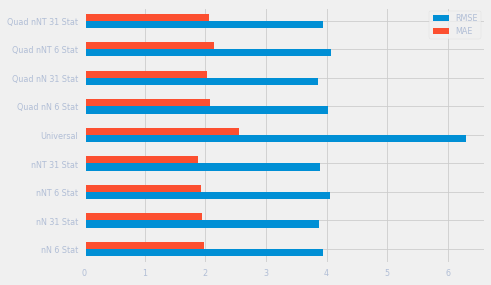

In [34]:
matplotlib.style.use('seaborn-paper')
subs.plot.barh()
#plt.savefig('horbar.png', dpi=300, format='png')

In [51]:
def label_barh(ax, bars, text_format, is_inside=True, **kwargs):
    """
    Attach a text label to each horizontal bar displaying its y value
    """
    max_y_value = max(bar.get_height() for bar in bars)
    if is_inside:
        distance = max_y_value
    else:
        distance = max_y_value * 0.01


    for bar in bars:
        text = text_format.format(bar.get_width())
        if is_inside:
            text_x = bar.get_width() - distance
        else:
            text_x = bar.get_width() + distance
        text_y = bar.get_y() + bar.get_height() / 2

        ax.text(text_x, text_y, text, va='center', **kwargs)

In [37]:
indices = subs.index.values
rmse = subs['RMSE'].values
mae = subs['MAE'].values
print(rmse)

[3.94409443 3.87469807 4.04976753 3.88687026 6.2895     4.0293
 3.8588     4.0728     3.9457    ]


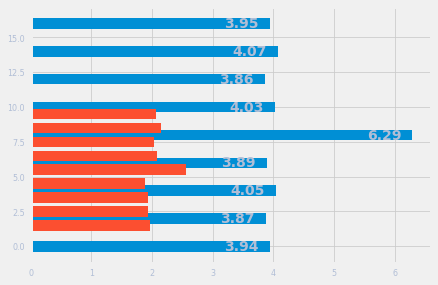

In [58]:
fig, ax = plt.subplots()
width = 0.75 # the width of the bars 
ind = np.arange(len(rmse))  # the x locations for the groups
#ax.barh(ind, rmse, width)
#ax.barh(ind, mae, width)
#ax.set_yticks(ind+width/2)
#ax.set_yticklabels(indices, minor=False)
#plt.title('title')
#plt.xlabel('x')
#plt.ylabel('y') 


hb1 = ax.barh(ind*2, rmse, width, align="center")
hb2 = ax.barh(ind+width*2, mae, width, align="center")
value_format = "{:.3}"  # displaying values as percentage with one fractional digit
label_barh(ax, hb1, value_format, is_inside=True, fontweight="bold")